# Part I – Discovering City Types
## Where should the lads go? Finding the ultimate cheap party city

In this notebook we group the 780 cities in the digital nomad dataset into **city types**,
and use them to answer one question for one specific audience.

## 1. Audience and question

**Our audience:** a group of friends in their early twenties planning a cheap, wild lads' holiday,
in the style of *The Hangover* or *The Inbetweeners*. They are not data people. They want a straight answer:

> **Which city, and which country, gives the most party for the least money, without being dangerous?**

| They care about | They do *not* care about |
|---|---|
| Low prices (living costs and beer) | Internet speed, coworking spaces |
| Nightlife | Press freedom, fragile states index |
| Things to do in the daytime | Costs for long-term expats |
| Being reasonably safe | |
| Being welcome as loud tourists | |

## 2. K-means or Archetypal Analysis?

Both methods group cities, but they describe a group in different ways:

| | K-means | Archetypal Analysis (AA) |
|---|---|---|
| Each city is… | in **exactly one** group | a **mix** of all types (e.g. 70 % type A, 30 % type B) |
| A type is described by… | the **average** city in the group (the centroid) | an **extreme** city on the edge of the data (the archetype) |
| Answers the question… | *"Which cities are similar?"* | *"What are the extremes, and how close is each city to them?"* |

**Our choice: AA.** Our audience is not looking for *"a group of fairly cheap cities with fairly good nightlife"*.
They are looking for **the most extreme combination** of low prices and a wild nightlife, and an archetype is exactly that extreme.
AA also gives every city a **share** of each archetype, so we can **rank** cities by how close they are to the "cheap party" extreme.
A K-means centroid is an average, so a good party city ends up in the same group as more average cities and the extreme gets watered down.

We still run K-means as well, and compare the two with the Adjusted Rand Index (ARI) later in the notebook.

## 3. Data
### 3.0 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import nnls

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

In [2]:
cities = pd.read_csv('https://sds-aau.github.io/SDS-master/M1/data/cities.csv')
print(cities.shape)
cities.head()

(780, 25)


,place,alpha-2,region,sub-region,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,...,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,Budapest,HU,Europe,Eastern Europe,1364.0,152.41,1273.0,1.73,1.73,1.0,...,52.7,28.17,1.0,0.27,0.6,0.40,0.80,0.86,1.00,0.0
1,Chiang Mai,TH,Asia,South-eastern Asia,777.0,98.88,780.0,0.85,0.85,0.8,...,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.75,0.40,0.0
2,Phuket,TH,Asia,South-eastern Asia,1012.0,155.43,1714.0,1.41,1.41,0.8,...,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.75,0.82,0.0
3,Bangkok,TH,Asia,South-eastern Asia,1197.0,131.41,1158.0,2.12,2.12,1.0,...,78.8,44.53,0.8,0.80,1.0,0.42,0.82,0.72,1.00,0.0
4,Ko Samui,TH,Asia,South-eastern Asia,1352.0,169.56,1347.0,1.41,1.41,0.8,...,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.80,0.0


### 3.1 Data quality checks
Before choosing features we check the data for problems.

In [3]:
print('Missing values:        ', cities.isna().sum().sum())
print('Duplicated cities:     ', cities.duplicated(['place', 'alpha-2']).sum())
print('coffee == beer, always:', (cities['coffee_in_cafe'] == cities['cost_beer']).all())

Missing values:         0
Duplicated cities:      0
coffee == beer, always: True


In [4]:
# racism should be a score between 0 and 1
cities['racism'].sort_values().tail(3)

191    1.000000e+00
47     1.000000e+00
518    1.818182e+28
Name: racism, dtype: float64

In [5]:
# a beer that costs 0 dollars?
print('Cities with beer price 0:', (cities['cost_beer'] == 0).sum())
cities.loc[cities['cost_beer'] == 0, ['place', 'alpha-2', 'sub-region', 'cost_nomad', 'cost_beer']].head(8)

Cities with beer price 0: 18


,place,alpha-2,sub-region,cost_nomad,cost_beer
17,New Taipei City,TW,Eastern Asia,2695.0,0.0
20,Tainan,TW,Eastern Asia,1398.0,0.0
125,Fez,US,Northern America,2735.0,0.0
164,Denpasar,ID,South-eastern Asia,1575.0,0.0
174,Surakarta,ID,South-eastern Asia,565.0,0.0
175,Semarang,ID,South-eastern Asia,566.0,0.0
176,Pekanbaru,ID,South-eastern Asia,610.0,0.0
177,Batam,ID,South-eastern Asia,927.0,0.0


In [6]:
# are the country codes right?
cities.loc[cities['place'].isin(['Fez', 'Hama']), ['place', 'alpha-2', 'region']]

,place,alpha-2,region
125,Fez,US,Americas
358,Hama,GB,Europe


**What we found**
- No missing values and no duplicated cities.
- `coffee_in_cafe` and `cost_beer` are **identical in every row**. The dataset uses one price for both, so we use only one of them (`cost_beer`, which matters more for our audience).
- `racism` should be between 0 and 1, but one city (Samara) has the value 1.8 × 10²⁸, which is clearly a data error.
  We do not use `racism` as a feature, so it does not affect our analysis. If we had used it, this one value would have
  dominated everything, especially in AA, where extreme points become archetypes.
- **18 cities have a beer price of exactly 0**, for example Denpasar (Bali). Free beer is not realistic, so these are
  missing values stored as 0. This matters a lot for us: with free beer these cities would look like perfect cheap party cities.
  We replace the 0s with the **median beer price in the same sub-region** (e.g. South-eastern Asia).
- Some **country codes are wrong** (Fez in Morocco is coded `US`, Hama in Syria is coded `GB`).
  This does not affect the clustering, but we must remember it when we go from cities to countries at the end.

In [7]:
cities['cost_beer'] = cities['cost_beer'].replace(0, np.nan)
cities['cost_beer'] = cities['cost_beer'].fillna(cities.groupby('sub-region')['cost_beer'].transform('median'))

print('Cities with beer price 0 now:', (cities['cost_beer'] == 0).sum())
cities.loc[cities['place'] == 'Denpasar', ['place', 'cost_beer']]

Cities with beer price 0 now: 0


,place,cost_beer
164,Denpasar,1.41


### 3.2 Choosing the features
We only use columns that matter to our audience:

| Feature | Why | What the lads want |
|---|---|---|
| `cost_nomad` | Total cost of staying in the city (USD / month) | Low |
| `cost_beer` | Price of a beer (USD) | Low |
| `nightlife` | The core of the trip | High |
| `leisure` | Things to do in the daytime | High |
| `safety` | They want to come home again | Not too low |
| `friendly_to_foreigners` | Loud tourists should be welcome | High |

In [8]:
features = ['cost_nomad', 'cost_beer', 'nightlife', 'leisure', 'safety', 'friendly_to_foreigners']
cities[features].describe().round(2)

,cost_nomad,cost_beer,nightlife,leisure,safety,friendly_to_foreigners
count,780.00,780.00,780.00,780.00,780.00,780.00
mean,2331.75,3.35,0.61,0.63,0.68,0.74
std,1118.12,1.93,0.23,0.20,0.21,0.18
min,387.00,0.09,0.00,0.00,0.00,0.00
25%,1486.00,1.68,0.40,0.45,0.60,0.60
50%,2208.50,3.11,0.60,0.60,0.60,0.80
75%,3057.00,4.63,0.80,0.80,0.80,0.80
max,10121.00,13.72,1.00,1.00,1.00,1.00


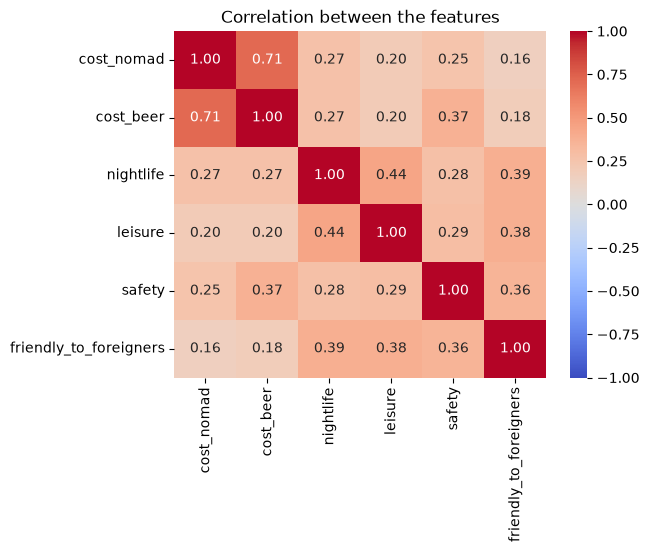

In [9]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(cities[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between the features')
plt.show()

**Two choices worth mentioning**
- `cost_nomad` and `cost_beer` are quite strongly correlated, so price counts roughly twice.
  We accept that, because price is our audience's most important criterion.
- We leave out `weed`. It is a yes/no column, and only about 12 % of the cities have a 1, so it would probably split the cities
  into "weed / no weed" instead of into party types.

### 3.3 Scaling
The features have very different units: `cost_nomad` is in thousands of dollars, while the scores are between 0 and 1.
Without scaling, `cost_nomad` would decide everything, so we standardise every feature to mean 0 and standard deviation 1.

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(cities[features])
X.shape

(780, 6)

## 4. Archetypal Analysis, by hand

AA describes every city as a **mix** of *k* archetypes, and every archetype as a **mix of real cities**.
The second rule keeps the archetypes on the edge of the data instead of outside it.
All mixing weights are ≥ 0 and add up to 1.

**Recipe** (similar to K-means by hand in the lecture)
1. **Start:** pick *k* random cities as the first archetypes
2. **Mix:** find the best mix of archetypes for every city
3. **Move:** find the archetypes that fit those mixes best, then pull them back to a mix of real cities
4. Repeat 2 and 3 until the error stops falling

We run the recipe from several random starts (`n_init`) and keep the best result, just like `KMeans(n_init=10)`.

In [11]:
def mix_weights(points, corners, M=200):
    """For every point: weights >= 0 that sum to 1, so that the weighted mix of the corners is as close as possible.
    The extra row of M's is a trick that forces the weights to sum to 1."""
    lhs = np.vstack([corners.T, M * np.ones(len(corners))])
    W = np.array([nnls(lhs, np.append(p, M))[0] for p in points])
    return W / W.sum(axis=1, keepdims=True)


def archetypal_analysis(X, k, n_init=5, max_iter=200, random_state=42):
    """Returns the archetypes (k x features), each city's mix of archetypes (cities x k) and the error (RSS)."""
    rng = np.random.default_rng(random_state)
    best = None
    for _ in range(n_init):
        Z = X[rng.choice(len(X), k, replace=False)]                 # 1. start: k random cities
        rss_old = np.inf
        for _ in range(max_iter):
            A = mix_weights(X, Z)                                   # 2. mix: each city as a mix of archetypes
            Z_free = np.linalg.lstsq(A, X, rcond=None)[0]           # 3. move: best archetypes for these mixes...
            Z = mix_weights(Z_free, X) @ X                          #    ...pulled back to a mix of real cities
            rss = ((X - A @ Z) ** 2).sum()
            if rss_old - rss < 1e-6 * rss_old:                      # 4. stop when the error stops falling
                break
            rss_old = rss
        A = mix_weights(X, Z)
        rss = ((X - A @ Z) ** 2).sum()
        if best is None or rss < best[2]:
            best = (Z, A, rss)
    return best

## 5. How many city types?

We try k = 2 to 8 with both methods:
- **K-means:** elbow method (inertia) and silhouette score, as in the lecture.
- **AA:** the share of the variation in the data that the archetypes explain. More archetypes always explain more,
  so we look for the point where adding one more stops giving much extra.

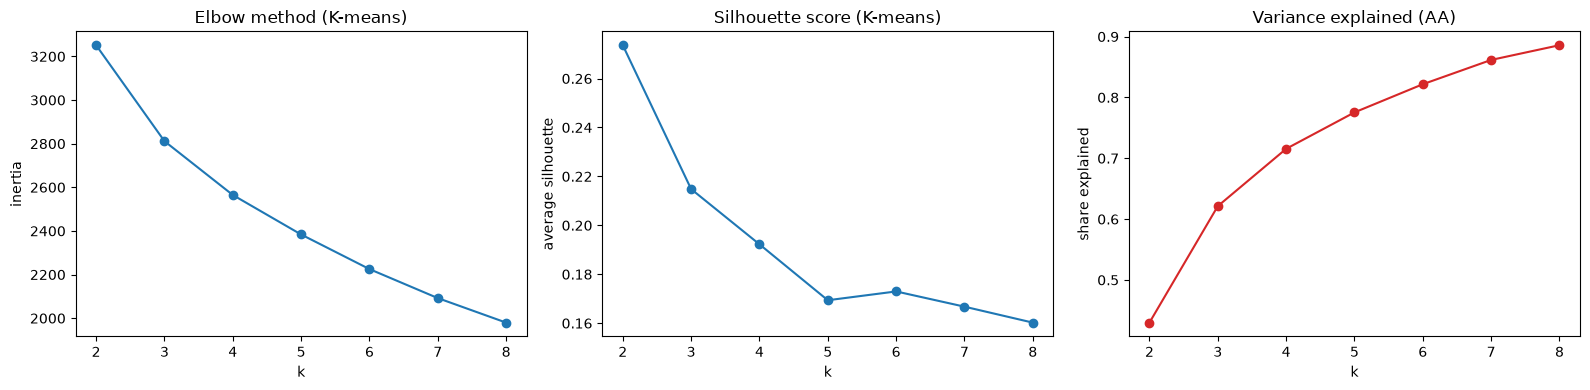

,k,inertia,silhouette,AA explained
0,2,3251.367,0.274,0.430
1,3,2811.538,0.215,0.621
2,4,2564.800,0.192,0.716
3,5,2383.709,0.169,0.775
4,6,2225.033,0.173,0.822
5,7,2092.140,0.167,0.862
6,8,1979.752,0.160,0.886


In [12]:
ks = range(2, 9)
total_ss = ((X - X.mean(axis=0)) ** 2).sum()
inertia, sil, aa_explained = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

    _, _, rss = archetypal_analysis(X, k)
    aa_explained.append(1 - rss / total_ss)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ks, inertia, marker='o')
axes[0].set(title='Elbow method (K-means)', xlabel='k', ylabel='inertia')
axes[1].plot(ks, sil, marker='o')
axes[1].set(title='Silhouette score (K-means)', xlabel='k', ylabel='average silhouette')
axes[2].plot(ks, aa_explained, marker='o', color='tab:red')
axes[2].set(title='Variance explained (AA)', xlabel='k', ylabel='share explained')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': ks, 'inertia': inertia, 'silhouette': sil, 'AA explained': aa_explained}).round(3)

**How to read it**
- The **elbow** curve for K-means has no sharp bend.
- The **silhouette** is highest at k = 2, but low overall (below 0.2 from k = 4). With k = 2 the cities are mostly split into
  cheap vs. expensive, which is too coarse for our audience. The low values also tell us something useful: the cities
  **do not form clearly separated clumps**. They lie on smooth gradients. That supports our choice of AA,
  which describes cities as mixes instead of forcing them into boxes.
- For **AA**, going from 3 to 4 archetypes still adds almost 10 percentage points of explained variance.
  After 4 the gains get smaller (about 6, 5, 4 …), so the curve bends around k = 4.

**We choose k = 4** for both methods. It is where the AA curve bends, and it is the last k before the silhouette drops clearly (from 4 to 5).
Also, 4 types are few enough for our audience to remember.
It is also enough to separate a "cheap party" type from cheaper but calmer or riskier cities.

## 6. Next steps (to do)
- **6. Fit both methods with k = 4:** K-means labels, AA archetypes and mixes. Give every type a human name.
- **7. Visualise for the audience:** a profile chart of each archetype, and the top 10 cities for the "cheap party" archetype.
- **8. Compare with ARI:** give each city its largest archetype and compare with the K-means labels.
- **9. Decide:** keep AA, switch methods, or conclude that the difference is not substantial.
- **10. Tell the story:** from city to country, and a final recommendation for the lads.

In [13]:
# TODO 6: fit K-means and AA with k = 4
k = 4
